# Jour 2 — TP : mini-rapport exploratoire

## Consignes

**Travail en groupe, sur VOTRE dataset nettoyé au Jour 1** (celui de votre dépôt Git).

**Partie 1 — fin de matinée : réponses chiffrées**
Reprenez les questions métier formulées au Jour 1. Pour **au moins 3 d'entre elles**, produisez le tableau qui y répond (`groupby`, `agg`, `pivot_table`, nouvelles variables…) et rédigez une phrase de réponse chiffrée.

**Partie 2 — après-midi : le mini-rapport**
Transformez vos analyses en un mini-rapport de **5 à 8 visualisations commentées**, structuré comme un vrai livrable professionnel (modèle ci-dessous).

**Rendu** : ce notebook complété, qui s'exécute du début à la fin sans erreur (*Kernel → Restart & Run All*), commité et poussé sur Git **avant la fin de la journée**, avec un message explicite (ex. `J2 - mini-rapport exploratoire`).

## Ce qu'on attend de chaque analyse

**Question → tableau → graphique → commentaire en 3 temps** (constat chiffré, interprétation, suite).

Rappels du cours :
- un titre de graphique **énonce le message**, il ne décrit pas ;
- un taux global = **ratio des sommes**, pas moyenne des ratios ;
- `nunique` pour compter des clients, `count` pour des lignes ;
- une comparaison semaine / week-end se ramène au **nombre de jours**.

## Checklist avant de rendre

- [ ] Le notebook tourne du début à la fin après *Restart & Run All*
- [ ] Chaque graphique a un titre-message, des axes nommés et des unités
- [ ] Chaque graphique est suivi de son commentaire en 3 temps
- [ ] La synthèse en tête du rapport est rédigée (et cohérente avec les analyses)
- [ ] Le périmètre (filtres, période, règles métier) est indiqué
- [ ] Le code est commenté et les cellules inutiles supprimées
- [ ] Commit + push effectués

## Grille d'évaluation (sur 20)

| Critère | Points | Ce qu'on regarde |
|---|---|---|
| Pertinence métier | 4 | Les questions ont un vrai intérêt pour l'activité ; les réponses y répondent vraiment |
| Justesse des agrégations | 4 | Bons indicateurs, bons filtres, ratios bien calculés, pas de double comptage |
| Choix et lisibilité des graphiques | 5 | Type adapté à la question, titres-messages, axes et unités, tri, sobriété |
| Qualité des commentaires | 4 | Chiffrés, interprétés avec prudence, débouchant sur une suite concrète |
| Structure et reproductibilité | 3 | Notebook propre et ordonné, code commenté, exécution complète sans erreur, commit Git |
| *Bonus* | +1 | Un graphique Plotly interactif réellement utile |

---

# *Smash : Analyse des ventes et des leviers de performance*

**Groupe :** *Jacques Callewaert*

**Contexte et périmètre :** *Cette analyse porte sur les données commerciales de Smash issues des tables commandes, clients et produits.  
Les trois tables sont reliées à partir des identifiants client et produit afin de construire une table analytique au niveau des lignes de commande.  
Conformément à la règle métier, seules les commandes ayant le statut **« Livrée »** sont prises en compte dans le chiffre d'affaires.  
Les principaux indicateurs étudiés sont le chiffre d'affaires, la marge, le panier, les clients distincts, les catégories, les villes, les modes de paiement et les canaux d'acquisition.*

## Synthèse

*Synthèse*

*L'analyse met en évidence plusieurs différences importantes dans les performances commerciales de Smash. Le chiffre d'affaires est concentré sur certaines villes et catégories, tandis que l'activité évolue également au cours de la période étudiée. Les comportements sont différents selon le mode de paiement, le canal d'acquisition et la présence d'une remise. Enfin, l'analyse de la marge montre qu'un chiffre d'affaires élevé ne signifie pas systématiquement une rentabilité plus élevée. Ces résultats permettent d'identifier les segments sur lesquels Smash peut concentrer ses actions commerciales.*

## Préparation des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titleweight"] = "bold"

# CHARGEMENT DES DONNÉES


commandes = pd.read_csv(
    "smash/commandes.csv",
    parse_dates=["date_commande"]
)

clients = pd.read_csv(
    "smash/clients.csv",
    parse_dates=["date_inscription"]
)

produits = pd.read_csv(
    "smash/produits.csv"
)


# JOINTURES

df = (
    commandes
    .merge(produits, on="produit_id", how="left")
    .merge(clients, on="client_id", how="left")
)

# INDICATEURS MÉTIER


df["montant"] = (
    df["quantite"]
    * df["prix_unitaire"]
    * (1 - df["remise"])
)

df["cout"] = (
    df["quantite"]
    * df["cout_unitaire"]
)

df["marge"] = df["montant"] - df["cout"]

# Seules les commandes livrées entrent dans le CA
ventes = df[df["statut"] == "Livrée"].copy()

print(f"{len(df)} lignes au total")
print(f"{len(ventes)} lignes correspondant à des commandes livrées")
print(
    f"Période : {ventes['date_commande'].min().date()} "
    f"au {ventes['date_commande'].max().date()}"
)

6500 lignes au total
5886 lignes correspondant à des commandes livrées
Période : 2025-01-01 au 2025-12-31


In [2]:
# Variables temporelles
ventes["annee"] = ventes["date_commande"].dt.year
ventes["mois_num"] = ventes["date_commande"].dt.month
ventes["mois"] = ventes["date_commande"].dt.to_period("M").astype(str)
ventes["trimestre"] = "T" + ventes["date_commande"].dt.quarter.astype(str)

# Tranches d'âge
ventes["tranche_age"] = pd.cut(
    ventes["age"],
    bins=[18, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "66+"],
    include_lowest=True
)

# Semaine / week-end
ventes["week_end"] = ventes["date_commande"].dt.dayofweek >= 5
ventes["type_jour"] = np.where(
    ventes["week_end"],
    "Week-end",
    "Semaine"
)

# Présence d'une remise
ventes["avec_remise"] = np.where(
    ventes["remise"] > 0,
    "Avec remise",
    "Sans remise"
)

# Contrôles rapides
print("CA total :", round(ventes["montant"].sum(), 2), "€")
print("Marge totale :", round(ventes["marge"].sum(), 2), "€")
print("Clients distincts :", ventes["client_id"].nunique())

CA total : 642688.78 €
Marge totale : 232616.59 €
Clients distincts : 984


## Analyses

### Analyse 1 : Des performances commerciales inégales selon les villes

**Question métier :** Dans quelles villes Smash réalise-t-il le plus de chiffre d'affaires ?

**Indicateurs et périmètre :** chiffre d'affaires et nombre de lignes de commande, commandes livrées uniquement.

In [3]:
analyse_ville = (
    ventes.groupby("ville")
    .agg(
        ca=("montant", "sum"),
        nb_lignes=("commande_id", "count"),
        clients=("client_id", "nunique")
    )
    .sort_values("ca", ascending=False)
)

analyse_ville.round(2)

,ca,nb_lignes,clients
ville,,,
Paris,203716.77,1890,302
Marseille,76379.65,680,110
Lyon,73584.98,666,131
Toulouse,68493.09,592,102
Bordeaux,65984.71,598,88
Lille,54826.04,514,79
Strasbourg,50905.39,443,81
Nantes,48798.15,503,91


In [4]:
top_ville = analyse_ville.iloc[0]

print(
    f"{analyse_ville.index[0]} arrive en tête avec "
    f"{top_ville['ca']:,.2f} € de CA, "
    f"pour {int(top_ville['nb_lignes'])} lignes de commande."
)

Paris arrive en tête avec 203,716.77 € de CA, pour 1890 lignes de commande.


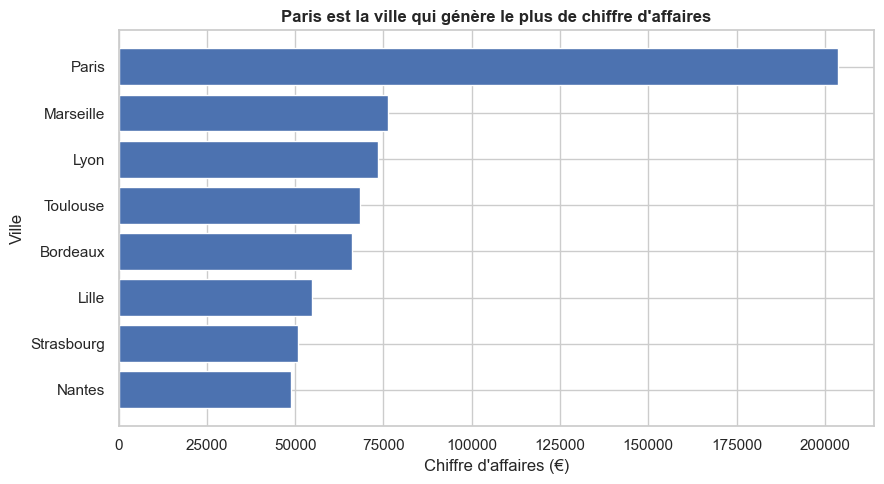

In [5]:
graph_ville = analyse_ville.sort_values("ca")

plt.figure(figsize=(9, 5))

plt.barh(
    graph_ville.index,
    graph_ville["ca"]
)

plt.title(
    f"{analyse_ville.index[0]} est la ville qui génère le plus de chiffre d'affaires"
)

plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Ville")

plt.tight_layout()
plt.show()

**Commentaire**
**Constat :** la première ville du classement concentre le chiffre d'affaires le plus élevé parmi les zones étudiées (Paris).

**Interprétation :** les performances géographiques de Smash ne sont donc pas homogènes. Cette différence peut provenir du nombre de clients, de leur fréquence d'achat ou de leur panier.

**Suite :** il serait intéressant de comparer le CA par client entre les villes afin de savoir si l'écart vient principalement du volume de clients ou de leur valeur.

### Analyse 2 — Les catégories qui vendent le plus ne sont pas forcément les plus rentables

**Question métier :** Quelles catégories de produits contribuent le plus au chiffre d'affaires et à la marge ?

**Indicateurs et périmètre :** CA, marge totale, taux de marge et clients distincts, commandes livrées uniquement.

In [6]:
analyse_cat = (
    ventes.groupby("categorie")
    .agg(
        ca=("montant", "sum"),
        marge=("marge", "sum"),
        clients=("client_id", "nunique"),
        quantite=("quantite", "sum")
    )
)

# Ratio des sommes, et non moyenne de ratios
analyse_cat["taux_marge_pct"] = (
    analyse_cat["marge"]
    / analyse_cat["ca"]
    * 100
)

analyse_cat = analyse_cat.sort_values(
    "ca",
    ascending=False
)

analyse_cat.round(2)

,ca,marge,clients,quantite,taux_marge_pct
categorie,,,,,
Électronique,235386.18,44011.28,464,1400,18.70
Maison,125041.48,50533.36,529,1679,40.41
Mode,115364.18,61577.69,582,2159,53.38
Beauté,73928.10,43690.91,520,1631,59.10
Sport,64992.64,25683.27,474,1409,39.52
Livres,27976.21,7120.08,418,1510,25.45


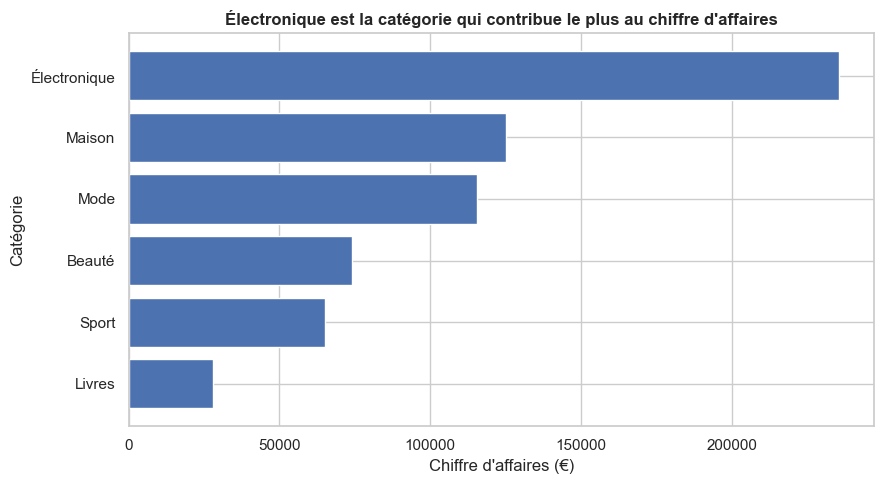

In [7]:
graph_cat = analyse_cat.sort_values("ca")

plt.figure(figsize=(9, 5))

plt.barh(
    graph_cat.index,
    graph_cat["ca"]
)

plt.title(
    f"{analyse_cat.index[0]} est la catégorie qui contribue le plus au chiffre d'affaires"
)

plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Catégorie")

plt.tight_layout()
plt.show()

**Commentaire**

**Constat :** certaines catégories occupent une place beaucoup plus importante que les autres dans le chiffre d'affaires et la marge.

**Interprétation :** un volume de ventes important ne suffit pas à mesurer la performance : la marge permet d'identifier les catégories qui apportent réellement le plus de valeur à l'entreprise.

**Suite :** Smash pourrait croiser ces résultats avec le nombre de clients et les remises afin d'identifier les catégories à développer en priorité.

### Analyse 3 — L'activité varie sensiblement au cours de la période

**Question métier :** Comment le chiffre d'affaires évolue-t-il mois après mois ?

**Indicateurs et périmètre :** chiffre d'affaires mensuel en k€, commandes livrées uniquement.

In [8]:
analyse_mois = (
    ventes
    .groupby("mois", as_index=False)
    .agg(
        ca=("montant", "sum"),
        nb_commandes=("commande_id", "nunique")
    )
)

analyse_mois["ca_ke"] = analyse_mois["ca"] / 1000

analyse_mois.round(2)

,mois,ca,nb_commandes,ca_ke
0,2025-01,45674.18,419,45.67
1,2025-02,33999.83,317,34.00
2,2025-03,48192.44,442,48.19
3,2025-04,45653.89,432,45.65
4,2025-05,50660.60,460,50.66
5,2025-06,47219.50,449,47.22
6,2025-07,43367.99,377,43.37
7,2025-08,27476.65,296,27.48
8,2025-09,50165.73,442,50.17
9,2025-10,56791.02,502,56.79


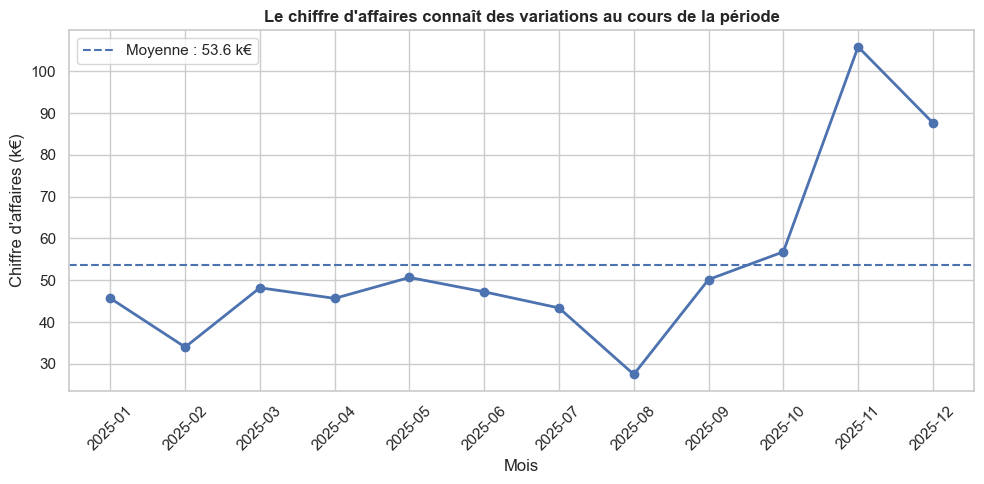

In [9]:
moyenne_mensuelle = analyse_mois["ca_ke"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    analyse_mois["mois"],
    analyse_mois["ca_ke"],
    marker="o",
    linewidth=2
)

plt.axhline(
    moyenne_mensuelle,
    linestyle="--",
    label=f"Moyenne : {moyenne_mensuelle:.1f} k€"
)

plt.title("Le chiffre d'affaires connaît des variations au cours de la période")

plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (k€)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
meilleur_mois = analyse_mois.loc[
    analyse_mois["ca"].idxmax()
]

moins_bon_mois = analyse_mois.loc[
    analyse_mois["ca"].idxmin()
]

print(
    f"Le mois le plus performant est {meilleur_mois['mois']} "
    f"avec {meilleur_mois['ca']:,.2f} € de CA."
)

print(
    f"Le mois le moins performant est {moins_bon_mois['mois']} "
    f"avec {moins_bon_mois['ca']:,.2f} €."
)

Le mois le plus performant est 2025-11 avec 105,834.91 € de CA.
Le mois le moins performant est 2025-08 avec 27,476.65 €.


**Commentaire**


**Constat :** le chiffre d'affaires n'est pas constant au cours de la période et certains mois se situent nettement au-dessus de la moyenne.

**Interprétation :** cela peut signaler une saisonnalité de l'activité, des périodes promotionnelles ou une variation de la demande.

**Suite :** il faudrait comparer ces périodes avec les volumes de commandes et les remises afin de déterminer ce qui explique précisément les pics de chiffre d'affaires.

### Analyse 4 — Le comportement d'achat varie selon le mode de paiement

**Question métier :** Les clients dépensent-ils le même montant selon leur mode de paiement ?

**Indicateurs et périmètre :** CA, panier moyen, panier médian, nombre de commandes et clients distincts.

In [11]:
analyse_paiement = (
    ventes.groupby("mode_paiement")
    .agg(
        ca=("montant", "sum"),
        nb_commandes=("commande_id", "nunique"),
        panier_moyen=("montant", "mean"),
        panier_median=("montant", "median"),
        clients=("client_id", "nunique")
    )
    .sort_values("panier_moyen", ascending=False)
)

analyse_paiement.round(2)

,ca,nb_commandes,panier_moyen,panier_median,clients
mode_paiement,,,,,
Paiement en 3x,131745.88,871,151.26,88.28,472
Virement,31384.77,301,104.27,63.76,231
PayPal,123410.03,1211,101.91,63.95,560
Carte bancaire,356148.10,3503,101.67,63.95,863


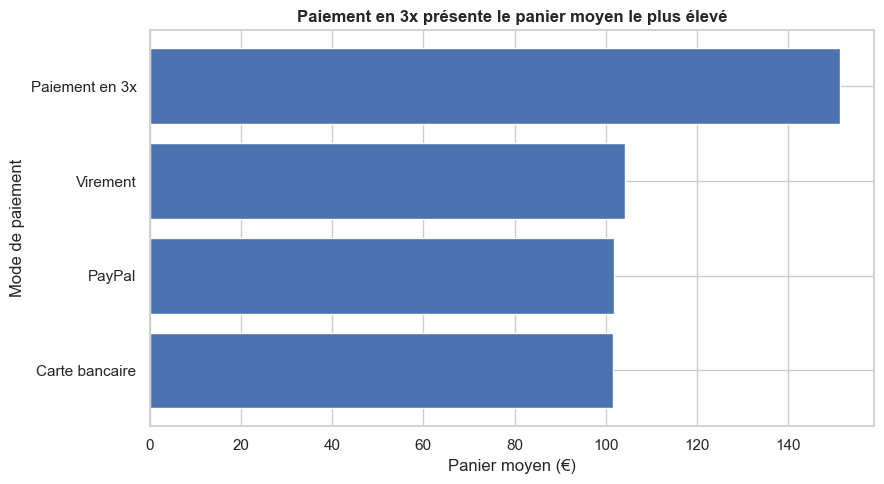

In [12]:
graph_paiement = analyse_paiement.sort_values(
    "panier_moyen"
)

plt.figure(figsize=(9, 5))

plt.barh(
    graph_paiement.index,
    graph_paiement["panier_moyen"]
)

plt.title(
    f"{analyse_paiement.index[0]} présente le panier moyen le plus élevé"
)

plt.xlabel("Panier moyen (€)")
plt.ylabel("Mode de paiement")

plt.tight_layout()
plt.show()

In [13]:
meilleur_mode = analyse_paiement.index[0]

print(
    f"{meilleur_mode} présente le panier moyen le plus élevé : "
    f"{analyse_paiement.loc[meilleur_mode, 'panier_moyen']:.2f} €."
)

Paiement en 3x présente le panier moyen le plus élevé : 151.26 €.


**Commentaire**

**Constat :** le panier moyen diffère selon le mode de paiement utilisé.

**Interprétation :** certains moyens de paiement peuvent être davantage utilisés pour des achats de valeur élevée. Cette relation reste toutefois descriptive et ne prouve pas que le mode de paiement provoque une hausse du panier.

**Suite :** on pourrait contrôler l'effet de la catégorie de produit afin de vérifier si la différence persiste à produits comparables.

### Analyse 5 — Les commandes remisées sont-elles réellement plus intéressantes ?

**Question métier :** Les commandes bénéficiant d'une remise présentent-elles un panier et une marge différents ?

**Indicateurs et périmètre :** nombre de commandes, panier moyen, CA et marge moyenne selon la présence ou non d'une remise.

In [14]:
analyse_remise = (
    ventes.groupby("avec_remise")
    .agg(
        nb_commandes=("commande_id", "nunique"),
        ca=("montant", "sum"),
        panier_moyen=("montant", "mean"),
        marge_moyenne=("marge", "mean"),
        marge_totale=("marge", "sum")
    )
)

analyse_remise.round(2)

,nb_commandes,ca,panier_moyen,marge_moyenne,marge_totale
avec_remise,,,,,
Avec remise,1894,185119.16,97.74,27.29,51695.70
Sans remise,3992,457569.62,114.62,45.32,180920.89


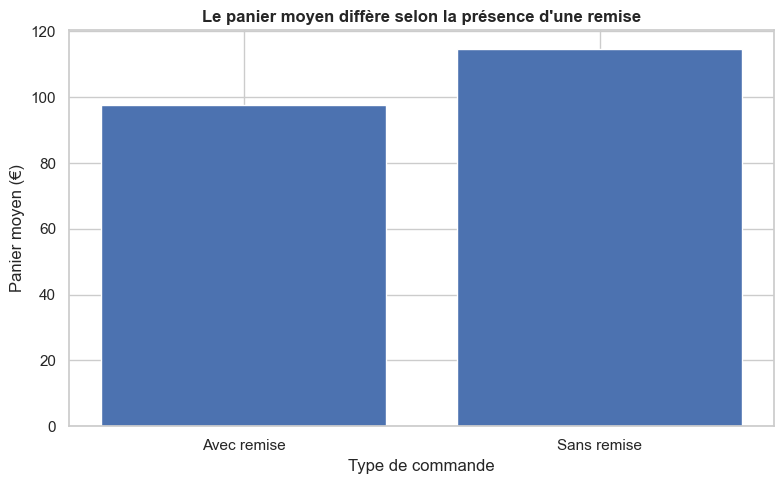

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    analyse_remise.index,
    analyse_remise["panier_moyen"]
)

plt.title("Le panier moyen diffère selon la présence d'une remise")
plt.xlabel("Type de commande")
plt.ylabel("Panier moyen (€)")

plt.tight_layout()
plt.show()

In [16]:
part_remise = (
    (ventes["remise"] > 0).sum()
    / len(ventes)
    * 100
)

print(
    f"{part_remise:.1f} % des lignes de vente bénéficient d'une remise."
)

32.2 % des lignes de vente bénéficient d'une remise.


**Commentaire**

**Constat :** le panier moyen et la marge diffèrent entre les ventes avec remise et celles sans remise.

**Interprétation :** une remise peut être associée à des paniers plus importants, mais elle réduit également le prix facturé et peut donc affecter la rentabilité.

**Suite :** il faudrait analyser les remises par catégorie afin de vérifier sur quels produits elles améliorent réellement le volume sans trop dégrader la marge.

### Analyse 6 — Tous les canaux d'acquisition n'apportent pas la même valeur client

**Question métier :** Quels canaux d'acquisition apportent les clients ayant la plus forte valeur ?

**Indicateurs et périmètre :** nombre de clients, CA moyen par client, commandes moyennes par client et panier moyen.

In [17]:
par_client = (
    ventes.groupby(
        ["client_id", "canal_acquisition"],
        as_index=False
    )
    .agg(
        ca_client=("montant", "sum"),
        nb_commandes=("commande_id", "nunique")
    )
)

par_client["panier_moyen_client"] = (
    par_client["ca_client"]
    / par_client["nb_commandes"]
)

par_client.head()

,client_id,canal_acquisition,ca_client,nb_commandes,panier_moyen_client
0,C0001,Publicité en ligne,2435.996,17,143.293882
1,C0002,Moteur de recherche,58.743,1,58.743000
2,C0004,Publicité en ligne,133.620,1,133.620000
3,C0005,Bouche-à-oreille,333.201,4,83.300250
4,C0006,Publicité en ligne,92.620,2,46.310000


In [18]:
analyse_canal = (
    par_client.groupby("canal_acquisition")
    .agg(
        nb_clients=("client_id", "nunique"),
        ca_moyen_client=("ca_client", "mean"),
        commandes_moyennes=("nb_commandes", "mean"),
        panier_moyen=("panier_moyen_client", "mean")
    )
    .sort_values("ca_moyen_client", ascending=False)
)

analyse_canal.round(2)

,nb_clients,ca_moyen_client,commandes_moyennes,panier_moyen
canal_acquisition,,,,
Moteur de recherche,302,686.98,5.98,111.80
Bouche-à-oreille,116,673.08,6.02,120.24
Réseaux sociaux,368,644.56,6.06,107.25
Publicité en ligne,198,605.78,5.81,98.74


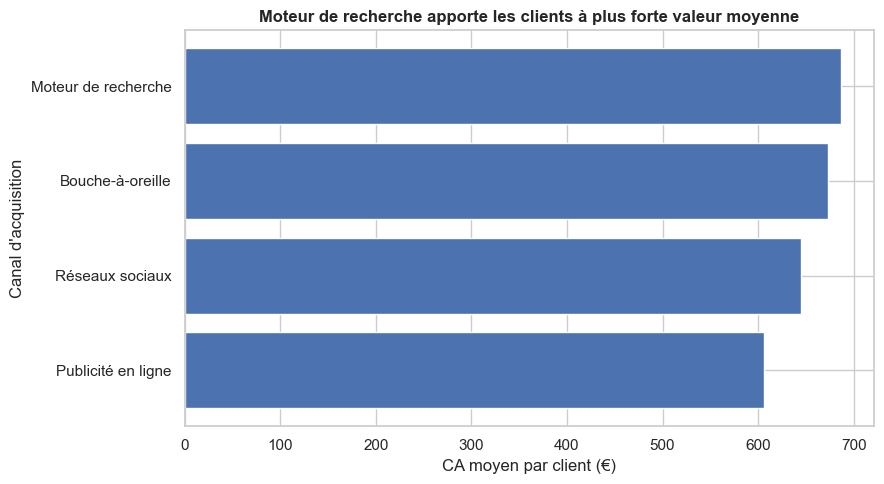

In [19]:
graph_canal = analyse_canal.sort_values(
    "ca_moyen_client"
)

plt.figure(figsize=(9, 5))

plt.barh(
    graph_canal.index,
    graph_canal["ca_moyen_client"]
)

plt.title(
    f"{analyse_canal.index[0]} apporte les clients à plus forte valeur moyenne"
)

plt.xlabel("CA moyen par client (€)")
plt.ylabel("Canal d'acquisition")

plt.tight_layout()
plt.show()

In [20]:
meilleur_canal = analyse_canal.index[0]

print(
    f"Le canal {meilleur_canal} présente le CA moyen par client "
    f"le plus élevé avec "
    f"{analyse_canal.loc[meilleur_canal, 'ca_moyen_client']:.2f} €."
)

Le canal Moteur de recherche présente le CA moyen par client le plus élevé avec 686.98 €.


**Commentaire**

**Constat :** la valeur moyenne d'un client varie selon son canal d'acquisition.

**Interprétation :** un canal qui génère beaucoup de clients n'est donc pas nécessairement celui qui génère les clients les plus rentables ou les plus actifs.

**Suite :** ces résultats pourraient être croisés avec le coût d'acquisition de chaque canal afin de calculer un véritable retour sur investissement marketing.

### Analyse 7 — L'activité quotidienne diffère-t-elle entre semaine et week-end ?

**Question métier :** Smash génère-t-il davantage de chiffre d'affaires par jour en semaine ou le week-end ?

**Indicateurs et périmètre :** CA quotidien moyen et commandes quotidiennes moyennes, commandes livrées uniquement.

In [21]:
ca_journalier = (
    ventes.groupby(
        ventes["date_commande"].dt.date
    )
    .agg(
        ca=("montant", "sum"),
        nb_commandes=("commande_id", "nunique")
    )
    .reset_index()
)

ca_journalier["date_commande"] = pd.to_datetime(
    ca_journalier["date_commande"]
)

ca_journalier["type_jour"] = np.where(
    ca_journalier["date_commande"].dt.dayofweek >= 5,
    "Week-end",
    "Semaine"
)

In [22]:
analyse_jour = (
    ca_journalier.groupby("type_jour")
    .agg(
        nb_jours=("date_commande", "count"),
        ca_moyen_jour=("ca", "mean"),
        commandes_moyennes_jour=("nb_commandes", "mean")
    )
)

analyse_jour.round(2)

,nb_jours,ca_moyen_jour,commandes_moyennes_jour
type_jour,,,
Semaine,261,1717.54,15.20
Week-end,104,1869.34,18.46


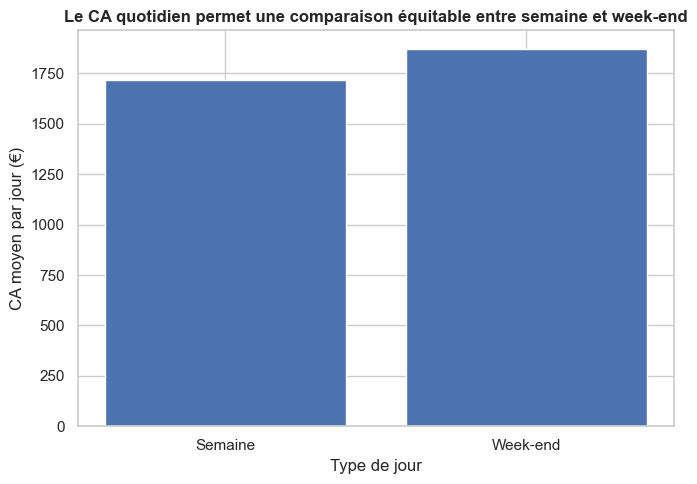

In [23]:
plt.figure(figsize=(7, 5))

plt.bar(
    analyse_jour.index,
    analyse_jour["ca_moyen_jour"]
)

plt.title("Le CA quotidien permet une comparaison équitable entre semaine et week-end")

plt.xlabel("Type de jour")
plt.ylabel("CA moyen par jour (€)")

plt.tight_layout()
plt.show()

**Commentaires**

**Constat :** le chiffre d'affaires quotidien moyen permet de comparer correctement les jours de semaine et de week-end.

**Interprétation :** utiliser les chiffres d'affaires totaux aurait été trompeur car une semaine compte cinq jours ouvrés contre seulement deux jours de week-end.

**Suite :** il serait intéressant d'étudier le détail par jour de la semaine afin d'identifier les journées les plus stratégiques pour les actions commerciales.

#### **Bonus Plotly interactif**

In [24]:
plotly_canal = analyse_canal.reset_index()

fig = px.bar(
    plotly_canal,
    x="canal_acquisition",
    y="ca_moyen_client",
    hover_data={
        "nb_clients": True,
        "commandes_moyennes": ":.2f",
        "panier_moyen": ":.2f",
        "ca_moyen_client": ":.2f"
    },
    labels={
        "canal_acquisition": "Canal d'acquisition",
        "ca_moyen_client": "CA moyen par client (€)",
        "nb_clients": "Clients",
        "commandes_moyennes": "Commandes moyennes / client",
        "panier_moyen": "Panier moyen (€)"
    },
    title="Les canaux d'acquisition apportent des clients de valeur différente"
)

fig.show()

## Limites et pistes pour le Jour 3


### Limites

- L'analyse porte uniquement sur les commandes livrées pour les indicateurs de chiffre d'affaires.
- Les relations observées sont descriptives et ne permettent pas d'établir directement une causalité.
- Certaines catégories, villes ou tranches de clients peuvent contenir moins d'observations que d'autres.
- Le chiffre d'affaires ne suffit pas à mesurer la performance : la marge doit également être prise en compte.
- Les performances des canaux d'acquisition sont analysées sans information sur leur coût marketing.

### Pistes

- Étudier plus précisément le lien entre remise, volume de ventes et marge.
- Construire une segmentation des clients selon leur valeur et leur fréquence d'achat.
- Analyser la fidélisation et le taux de réachat.
- Étudier la saisonnalité par catégorie de produit.
- Ajouter les coûts d'acquisition afin de comparer la rentabilité réelle des canaux marketing.